# Dati dummy in CSV

### Heatmap gaussiana generica

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
columns = ['latitude', 'longitude', 'value']

(12.750882,52.413184,12.762719,52.422736)

lat_values = np.linspace(45, 45.5, 1000)
lon_values = np.linspace(10, 10.5, 1000)
lon_grid, lat_grid = np.meshgrid(lon_values, lat_values)

# Center of the Gaussian (in lat/lon)
lat0 = 45.25
lon0 = 10.25

# Standard deviations (controls the "spread")
sigma_lat = 0.5
sigma_lon = 0.5

# 2D Gaussian function
values = 1-np.exp(-(((lat_grid - lat0)**2) / (2 * sigma_lat**2) +
                    ((lon_grid - lon0)**2) / (2 * sigma_lon**2)))

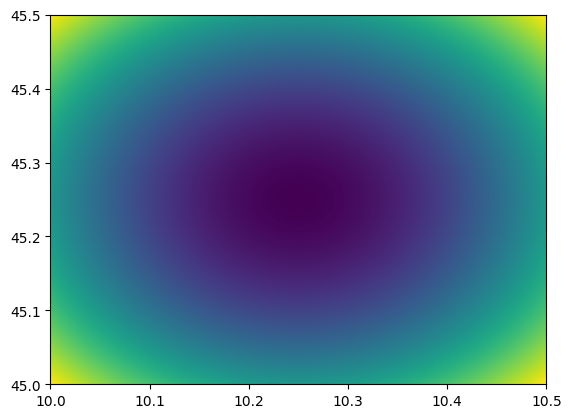

In [5]:
plt.imshow(values, extent=[lon_values.min(), lon_values.max(), lat_values.min(), lat_values.max()],
           origin='lower', aspect='auto', cmap='viridis')

In [6]:
data = np.zeros((1000,1000,3))
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        data[i,j,0] = lat_values[i]
        data[i,j,1] = lon_values[j]
        data[i,j,2] = values[i,j]

data = data.reshape(-1, 3)
df = pd.DataFrame(data, columns=columns)

df.to_csv('data.csv', index=False)

In [7]:
df

,latitude,longitude,value
0,45.0,10.000000,0.221199
1,45.0,10.000501,0.220810
2,45.0,10.001001,0.220421
3,45.0,10.001502,0.220032
4,45.0,10.002002,0.219645
...,...,...,...
999995,45.5,10.497998,0.219645
999996,45.5,10.498498,0.220032
999997,45.5,10.498999,0.220421
999998,45.5,10.499499,0.220810


### Heatmap "geopardizzata"

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

columns = ['latitude', 'longitude', 'value']

def get_jeopardize(lat_lims = None, lon_lims = None, lat_res = None, lon_res = None):
    #['+12.749788','+52.410025','+12.765038','+52.4254093']
    #lat_lims = [52.410025, 52.4254093]
    #lon_lims = [12.74978, 12.765038]
    if lat_lims is None:
        lat_lims = [52.413184, 52.422736]
    if lon_lims is None:
        lon_lims = [12.750882, 12.762719]
    if lat_res is None:
        lat_res = 1000
    if lon_res is None:
        lon_res = 1000

    # Create grid of lat/lon values
    lat_values = np.linspace(lat_lims[0], lat_lims[1], lat_res)
    lon_values = np.linspace(lon_lims[0], lon_lims[1], lon_res)
    lon_grid, lat_grid = np.meshgrid(lon_values, lat_values)

    # Parameters for the two "zones" of interest
    lat_center_1, lon_center_1 = lat_lims[0] + np.random.rand(), lon_lims[0] + np.random.rand()  # First high-value center
    lat_center_2, lon_center_2 = lat_lims[0] + np.random.rand(), lon_lims[0] + np.random.rand() # Second high-value center

    # Standard deviations (controls the "spread")
    sigma_lat = 0.02
    sigma_lon = 0.02

    # Generate two Gaussian bumps (for two zones)
    bump1 = np.exp(-(((lat_grid - lat_center_1)**2) / (2 * sigma_lat**2) + ((lon_grid - lon_center_1)**2) / (2 * sigma_lon**2)))
    bump2 = np.exp(-(((lat_grid - lat_center_2)**2) / (2 * sigma_lat**2) + ((lon_grid - lon_center_2)**2) / (2 * sigma_lon**2)))

    # Combine the bumps to form a field that has two high-value regions
    combined_field = bump1 + bump2

    # Add random noise to increase variability
    random_noise = np.random.normal(loc=0, scale=10, size=combined_field.shape)  # Mean 0, std 10
    combined_field += random_noise

    # Smooth the combined field for a smooth transition between zones
    smoothed_field = gaussian_filter(combined_field, sigma=50)

    # Normalize the values to be between 0 and 100
    smoothed_field = np.clip(smoothed_field, 0, 100)
    return smoothed_field, lat_values, lon_values

In [5]:
lat_res = 104
lon_res = 84
lat_lims = [52.413184, 52.422736]
lon_lims = [12.750882, 12.762719]

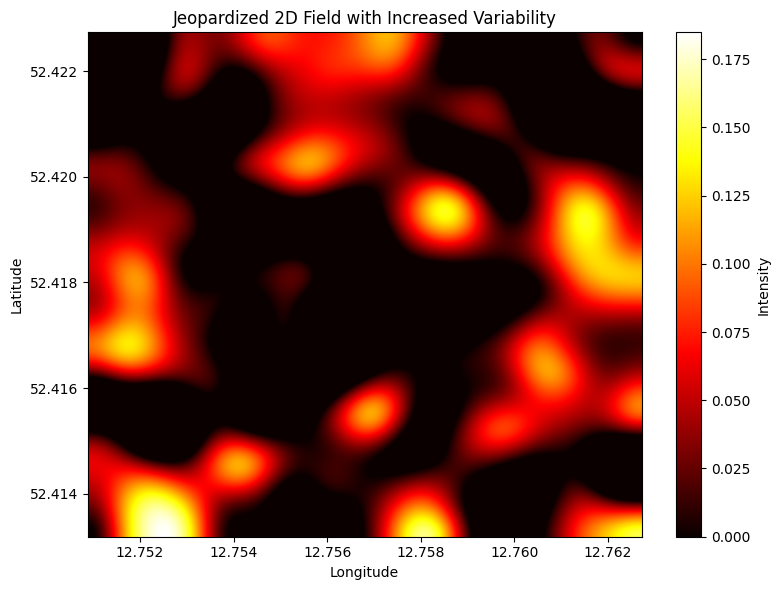

In [8]:
smoothed_field, lat_values, lon_values = get_jeopardize()

# Plot with imshow
plt.figure(figsize=(8, 6))
plt.imshow(smoothed_field, extent=[lon_values.min(), lon_values.max(), lat_values.min(), lat_values.max()],
           origin='lower', cmap='hot', aspect='auto')

plt.colorbar(label='Intensity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Jeopardized 2D Field with Increased Variability')
plt.tight_layout()
plt.show()


In [11]:
n_heatmaps = 4
n_times = 4
for s in range(n_heatmaps):
    for t in range(n_times):
        smoothed_field, lat_values, lon_values = get_jeopardize(lat_lims, lon_lims, lat_res, lon_res)
        data = np.zeros((lat_res,lon_res,3))
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                data[i,j,0] = lat_values[i]
                data[i,j,1] = lon_values[j]
                data[i,j,2] = smoothed_field[i,j]

        data = data.reshape(-1, 3)
        df = pd.DataFrame(data, columns=columns)

        df.to_csv(f'data/data_sectors_{s}_{t}.csv', index=False)

## Mappa a settori 2x2

In [ ]:

for s in range(4):
    for t in range(4):
        data = np.zeros((2,2,3))
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                data[i,j,0] = lat_values[i]
                data[i,j,1] = lon_values[j]
                data[i,j,2] = np.random.randint(0, 100)

        data = data.reshape(-1, 3)
        df = pd.DataFrame(data, columns=columns)

        df.to_csv(f'data/data_sectors_{s}_{t}.csv', index=False)